# Data Import
Load JSON Lines files into Polars DataFrames for analysis.

In [1]:
# Imports
import json
import polars as pl
from pathlib import Path
from tqdm import tqdm

print("Imports OK")

Imports OK


In [2]:
# Configuration
DATA_DIR = Path("../data")
MODEL_FILE = DATA_DIR / "data-model-snapshop.json"
PREDICTOR_FILE = DATA_DIR / "data-Predictor-binning-snapshot.json"

def load_jsonl(filepath: Path, description: str = "Loading") -> list[dict]:
    """Load a JSON Lines file into a list of dictionaries.
    
    Args:
        filepath: Path to the .jsonl file
        description: Description for progress bar
    
    Returns:
        List of JSON objects
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for _ in f)
    
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=total_lines, desc=description):
            records.append(json.loads(line))
    
    return records

# Load Model Snapshots
print("Loading model snapshots...")
model_records = load_jsonl(MODEL_FILE, "Model snapshots")
df_model_snapshots = pl.DataFrame(model_records)
print(f"  → {len(df_model_snapshots)} records, {len(df_model_snapshots.columns)} columns")

# Load Predictor Binning Snapshots
print("Loading predictor binning snapshots...")
predictor_records = load_jsonl(PREDICTOR_FILE, "Predictor binning")
df_predictor_binning = pl.DataFrame(predictor_records)
print(f"  → {len(df_predictor_binning)} records, {len(df_predictor_binning.columns)} columns")

print("\n✓ Data loaded successfully")

Loading model snapshots...


Model snapshots: 100%|██████████| 161704/161704 [00:01<00:00, 105809.68it/s]


  → 161704 records, 27 columns
Loading predictor binning snapshots...


Predictor binning: 100%|██████████| 222348/222348 [00:03<00:00, 73692.48it/s]


  → 222348 records, 34 columns

✓ Data loaded successfully


# Data Inspection
Explore the structure and content of both datasets.

In [3]:
# --- Model Snapshots ---
# One record per model (or model version)
print("=" * 60)
print("MODEL SNAPSHOTS")
print("=" * 60)

print(f"\nShape: {df_model_snapshots.shape}")
print(f"\nColumns:\n{df_model_snapshots.columns}")

print("\n--- Sample record ---")
df_model_snapshots.head(1).to_dicts()[0]

MODEL SNAPSHOTS

Shape: (161704, 27)

Columns:
['pyAppliesToClass', 'pyModelID', 'pyTotalPredictors', 'pxApplication', 'pyPerformance', 'pyPerformanceError', 'pyResponseCount', 'pyConfigurationName', 'pyFactoryUpdateTime', 'pyChannel', 'pyName', 'pyTreatment', 'pyDirection', 'pySnapshotTime', 'pxInsName', 'pyModelTechnique', 'pxSaveDateTime', 'pySuccessRate', 'pyGroup', 'pyNegatives', 'pyActivePredictors', 'pyPositives', 'pzInsKey', 'pyModelVersion', 'pxCommitDateTime', 'pyModelData', 'pyIssue']

--- Sample record ---


{'pyAppliesToClass': 'Data-Decision-Request-Customer',
 'pyModelID': '00116756-b49c-5a7a-a8cf-b503599fd40c',
 'pyTotalPredictors': 60,
 'pxApplication': 'PegaRULES',
 'pyPerformance': '0.500000',
 'pyPerformanceError': 0.0,
 'pyResponseCount': 113827.0,
 'pyConfigurationName': 'OmniAdaptiveModel',
 'pyFactoryUpdateTime': '20250909T100852.001 GMT',
 'pyChannel': 'Mobile',
 'pyName': 'DIVE',
 'pyTreatment': '',
 'pyDirection': 'Inbound',
 'pySnapshotTime': '20251017T050000.600 GMT',
 'pxInsName': '00116756-B49C-5A7A-A8CF-B503599FD40C!20251017T050000.600 GMT!PEGARULES',
 'pyModelTechnique': 'NaiveBayes',
 'pxSaveDateTime': '20251017T050056.206 GMT',
 'pySuccessRate': 0.0,
 'pyGroup': 'FlightAncillaries',
 'pyNegatives': 113827.0,
 'pyActivePredictors': 0,
 'pyPositives': 0.0,
 'pzInsKey': 'DATA-DECISION-ADM-MODELSNAPSHOT 00116756-B49C-5A7A-A8CF-B503599FD40C!20251017T050000.600 GMT!PEGARULES',
 'pyModelVersion': '635fbb86-0c06-5440-96b3-292c9abe6d98',
 'pxCommitDateTime': '20251017T050056.

In [4]:
# --- Predictor Binning Snapshots ---
# Multiple records per predictor (one per bin)
print("=" * 60)
print("PREDICTOR BINNING SNAPSHOTS")
print("=" * 60)

print(f"\nShape: {df_predictor_binning.shape}")
print(f"\nColumns:\n{df_predictor_binning.columns}")

# Unique predictors
unique_predictors = df_predictor_binning["pyPredictorName"].unique()
print(f"\n--- Predictor Summary ---")
print(f"Unique predictors: {len(unique_predictors)}")
print(f"Sample predictors: {unique_predictors[:5]}")

# Bins per predictor
bins_per_predictor = (
    df_predictor_binning
    .group_by("pyPredictorName")
    .agg(pl.len().alias("num_bins"))
    .sort("num_bins", descending=True)
)
print(f"\n--- Bins per Predictor (top 10) ---")
bins_per_predictor.head(10)

PREDICTOR BINNING SNAPSHOTS

Shape: (222348, 34)

Columns:
['pyBinResponseCountPercentage', 'pyContents', 'pyZRatio', 'pyModelID', 'pyBinType', 'pyBinSymbol', 'pyPredictorName', 'pyBinPositivesPercentage', 'pyBinNegativesPercentage', 'pyBinNegatives', 'pyType', 'pyBinLowerBound', 'pyPerformance', 'pyPerformanceError', 'pyResponseCount', 'pxCreateDateTime', 'pyBinIndex', 'pyLift', 'pyBinUpperBound', 'pyFeatureImportance', 'pySnapshotTime', 'pxInsName', 'pyTotalBins', 'pxSaveDateTime', 'pyNegatives', 'pyPositives', 'pyGroupIndex', 'pyEntryType', 'pzInsKey', 'pyBinPositives', 'pyBinResponseCount', 'pxCommitDateTime', 'pyRuleSetName', 'pxUpdateDateTime']

--- Predictor Summary ---
Unique predictors: 606
Sample predictors: shape: (5,)
Series: 'pyPredictorName' [str]
[
	"Customer.PreviousFlight.INBOUN…
	"CurrentContext.Extras.ADMPropA…
	"Customer.PreviousFlight.IsRetu…
	"CustBookedFlight.FlightData.Ai…
	"CustBookedFlight.CountryCallin…
]

--- Bins per Predictor (top 10) ---


pyPredictorName,num_bins
str,u32
"""Classifier""",12793
"""IH.Event.Outbound.RealTimeEven…",3129
"""IH.Email.Inbound.Delivered.pxL…",2984
"""IH.Email.Inbound.Pending.pxLas…",2956
"""IH.Email.Outbound.Pending.pxLa…",2918
"""IH.Email.Outbound.Delivered.px…",2870
"""IH.Email.Outbound.Clicked.pxLa…",2851
"""IH.Email.Outbound.Pending.pyHi…",2591
"""IH.Email.Inbound.Rejected.pxLa…",2477


In [5]:
# --- Key differences between datasets ---
print("=" * 60)
print("DATASET RELATIONSHIP")
print("=" * 60)

# Model ID links both datasets
model_ids_model = df_model_snapshots["pyModelID"].unique().to_list() if "pyModelID" in df_model_snapshots.columns else []
model_ids_predictor = df_predictor_binning["pyModelID"].unique().to_list()

print(f"\nModel IDs in model snapshots: {len(model_ids_model)}")
print(f"Model IDs in predictor binning: {len(model_ids_predictor)}")

if model_ids_model:
    common = set(model_ids_model) & set(model_ids_predictor)
    print(f"Common model IDs: {len(common)}")

DATASET RELATIONSHIP

Model IDs in model snapshots: 963
Model IDs in predictor binning: 963
Common model IDs: 963


# Feature Importance Analysis
Analyze the `pyFeatureImportance` field from predictor binning snapshots.

In [6]:
# --- Feature Importance Distribution ---
print("=" * 60)
print("FEATURE IMPORTANCE DISTRIBUTION")
print("=" * 60)

# Basic stats
importance_col = df_predictor_binning["pyFeatureImportance"]
print(f"\n--- Summary Statistics ---")
print(importance_col.describe())

# Distribution by importance ranges (using lit() for string literals)
print(f"\n--- Importance Range Distribution ---")
df_importance_cats = (
    df_predictor_binning
    .with_columns(
        pl.when(pl.col("pyFeatureImportance") == 0)
        .then(pl.lit("Zero"))
        .when(pl.col("pyFeatureImportance") < 0.01)
        .then(pl.lit("Low (0-0.01)"))
        .when(pl.col("pyFeatureImportance") < 0.1)
        .then(pl.lit("Medium (0.01-0.1)"))
        .otherwise(pl.lit("High (>0.1)"))
        .alias("importance_category")
    )
)
df_importance_cats.group_by("importance_category").agg(pl.len().alias("count")).sort("count", descending=True)

FEATURE IMPORTANCE DISTRIBUTION

--- Summary Statistics ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 222348.0 │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.267801 │
│ std        ┆ 0.303455 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.028769 │
│ 50%        ┆ 0.164032 │
│ 75%        ┆ 0.413072 │
│ max        ┆ 4.462969 │
└────────────┴──────────┘

--- Importance Range Distribution ---


importance_category,count
str,u32
"""High (>0.1)""",134986
"""Medium (0.01-0.1)""",41188
"""Low (0-0.01)""",26227
"""Zero""",19947


In [7]:
# --- Top Features by Importance ---
print("=" * 60)
print("TOP FEATURES BY IMPORTANCE")
print("=" * 60)

# Aggregate importance by predictor (sum across bins)
predictor_importance = (
    df_predictor_binning
    .group_by("pyPredictorName")
    .agg(
        pl.sum("pyFeatureImportance").alias("total_importance"),
        pl.len().alias("num_bins"),
        pl.first("pyType").alias("type"),
        pl.first("pyModelID").alias("model_id")
    )
    .sort("total_importance", descending=True)
)

print(f"\n--- Top 15 Predictors by Total Importance ---")
print(predictor_importance.head(15))

# Show non-zero importance predictors
print(f"\n--- Predictors with Non-Zero Importance ---")
non_zero = predictor_importance.filter(pl.col("total_importance") > 0)
print(f"Total: {len(non_zero)} predictors with importance > 0")
print(non_zero.head(10))

TOP FEATURES BY IMPORTANCE

--- Top 15 Predictors by Total Importance ---
shape: (15, 5)
┌─────────────────────────────┬──────────────────┬──────────┬─────────┬────────────────────────────┐
│ pyPredictorName             ┆ total_importance ┆ num_bins ┆ type    ┆ model_id                   │
│ ---                         ┆ ---              ┆ ---      ┆ ---     ┆ ---                        │
│ str                         ┆ f64              ┆ u32      ┆ str     ┆ str                        │
╞═════════════════════════════╪══════════════════╪══════════╪═════════╪════════════════════════════╡
│ IH.Event.Outbound.RealTimeE ┆ 1034.317377      ┆ 3129     ┆ numeric ┆ 00118d29-b883-53fc-8e58-03 │
│ ven…                        ┆                  ┆          ┆         ┆ c50b…                      │
│ IH.Mobile.Inbound.Impressio ┆ 982.655994       ┆ 2145     ┆ numeric ┆ 00118d29-b883-53fc-8e58-03 │
│ n.p…                        ┆                  ┆          ┆         ┆ c50b…                      │
│ 

# Feature Importance Visualization
Plots to visualize feature importance distributions.

In [8]:
# --- Visualizations ---
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Distribution histogram of feature importance
fig1 = px.histogram(
    df_predictor_binning.to_pandas(), 
    x="pyFeatureImportance",
    nbins=50,
    title="Distribution of Feature Importance (per bin)",
    labels={"pyFeatureImportance": "Feature Importance"}
)
fig1.show()

# 2. Top 20 predictors by total importance
top20 = predictor_importance.head(20).to_pandas()
fig2 = px.bar(
    top20, 
    x="total_importance", 
    y="pyPredictorName", 
    orientation='h',
    title="Top 20 Predictors by Total Importance",
    labels={"total_importance": "Total Importance", "pyPredictorName": "Predictor"}
)
fig2.update_layout(yaxis=dict(autorange="reversed"))
fig2.show()

# 3. Importance by type (numeric vs categorical)
type_importance = (
    df_predictor_binning
    .group_by("pyType")
    .agg(pl.sum("pyFeatureImportance").alias("total_importance"))
    .to_pandas()
)
fig3 = px.pie(type_importance, values="total_importance", names="pyType", title="Importance by Predictor Type")
fig3.show()

### Offer Selection: Service – FlightInfo – OnlineFlightCheckinOpen


To select a suitable model for further analysis, we evaluated candidate offers using model snapshot data from Pega ADM. For each offer, we filtered the model snapshots on issue, group, and name, and assessed key indicators of model viability, including the number of snapshots (temporal coverage), response volume, number of positive outcomes, number of active predictors, and model performance.

For the selected offer (Service – FlightInfo – OnlineFlightCheckinOpen), the results show strong suitability: the model has been updated frequently over time (184 snapshots), has a high response volume (over 10 million observations), and a substantial number of positive outcomes (over 5 million), indicating sufficient learning signal. Additionally, the model uses a non-trivial number of predictors (up to 24 active predictors out of 243 total), and achieves reasonable performance (average ~0.70).

These characteristics indicate that the model is actively learning, well-supported by data, and sufficiently complex, making it a suitable candidate for further analysis of predictor behavior and explanation stability.

In [9]:
import polars as pl

TARGET_ISSUE = "Service"
TARGET_GROUP = "FlightInfo"
TARGET_NAME = "OnlineFlightCheckinOpen"

offer_df = df_model_snapshots.filter(
    (pl.col("pyIssue") == TARGET_ISSUE) &
    (pl.col("pyGroup") == TARGET_GROUP) &
    (pl.col("pyName") == TARGET_NAME)
)

print("\n" + "=" * 60)
print(f"CHECKING OFFER: {TARGET_ISSUE} / {TARGET_GROUP} / {TARGET_NAME}")
print("=" * 60)
print(f"\nNumber of snapshot rows: {offer_df.height}")

if offer_df.height == 0:
    print("No model snapshots found for this offer.")
else:
    # Cast numeric columns safely
    offer_df = offer_df.with_columns([
        pl.col("pyResponseCount").cast(pl.Float64, strict=False),
        pl.col("pyPositives").cast(pl.Float64, strict=False),
        pl.col("pyNegatives").cast(pl.Float64, strict=False),
        pl.col("pyActivePredictors").cast(pl.Float64, strict=False),
        pl.col("pyTotalPredictors").cast(pl.Float64, strict=False),
        pl.col("pyPerformance").cast(pl.Float64, strict=False),
        pl.col("pySuccessRate").cast(pl.Float64, strict=False),
    ])

    print("\n--- Basic overview ---")
    print(
        offer_df.select([
            pl.col("pyModelID").n_unique().alias("n_model_ids"),
            pl.col("pySnapshotTime").n_unique().alias("n_snapshots"),
            pl.col("pyResponseCount").max().alias("max_response_count"),
            pl.col("pyResponseCount").mean().alias("avg_response_count"),
            pl.col("pyPositives").max().alias("max_positives"),
            pl.col("pyPositives").sum().alias("sum_positives"),
            pl.col("pyActivePredictors").max().alias("max_active_predictors"),
            pl.col("pyTotalPredictors").max().alias("max_total_predictors"),
            pl.col("pyPerformance").max().alias("max_performance"),
            pl.col("pyPerformance").mean().alias("avg_performance"),
        ])
    )

    print("\n--- Snapshot progression (latest 10) ---")
    cols_to_show = [
        c for c in [
            "pySnapshotTime",
            "pyModelID",
            "pyResponseCount",
            "pyPositives",
            "pyNegatives",
            "pyActivePredictors",
            "pyTotalPredictors",
            "pyPerformance",
            "pySuccessRate",
        ] if c in offer_df.columns
    ]

    print(
        offer_df
        .sort("pySnapshotTime")
        .select(cols_to_show)
        .tail(10)
    )

    max_resp = offer_df["pyResponseCount"].max()
    max_pos = offer_df["pyPositives"].max()
    max_active = offer_df["pyActivePredictors"].max()
    n_snapshots = offer_df["pySnapshotTime"].n_unique()

    print("\n--- Decision checks ---")
    print(f"Enough snapshots (>20)? {'YES' if n_snapshots > 20 else 'NO'}  [{n_snapshots}]")
    print(f"Has learning signal (positives > 0)? {'YES' if (max_pos or 0) > 0 else 'NO'}  [{max_pos}]")
    print(f"Has active predictors (>0)? {'YES' if (max_active or 0) > 0 else 'NO'}  [{max_active}]")
    print(f"Reasonable response volume (>200)? {'YES' if (max_resp or 0) > 200 else 'NO'}  [{max_resp}]")


CHECKING OFFER: Service / FlightInfo / OnlineFlightCheckinOpen

Number of snapshot rows: 516

--- Basic overview ---
shape: (1, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ n_model_i ┆ n_snapsho ┆ max_respo ┆ avg_respo ┆ … ┆ max_activ ┆ max_total ┆ max_perfo ┆ avg_perf │
│ ds        ┆ ts        ┆ nse_count ┆ nse_count ┆   ┆ e_predict ┆ _predicto ┆ rmance    ┆ ormance  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ors       ┆ rs        ┆ ---       ┆ ---      │
│ u32       ┆ u32       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 4         ┆ 184       ┆ 1.0678756 ┆ 6.7741e6  ┆ … ┆ 24.0      ┆ 243.0     ┆ 0.99884   ┆ 0.697939 │
│           ┆           ┆ e7        ┆           ┆   ┆      

## Offer Comparison: Sales – Luggage – L5B15


In [10]:
import polars as pl

TARGET_ISSUE = "Sales"
TARGET_GROUP = "Luggage"
TARGET_NAME = "L5B15"

offer_df = df_model_snapshots.filter(
    (pl.col("pyIssue") == TARGET_ISSUE) &
    (pl.col("pyGroup") == TARGET_GROUP) &
    (pl.col("pyName") == TARGET_NAME)
)

print("\n" + "=" * 60)
print(f"CHECKING OFFER: {TARGET_ISSUE} / {TARGET_GROUP} / {TARGET_NAME}")
print("=" * 60)
print(f"\nNumber of snapshot rows: {offer_df.height}")

if offer_df.height == 0:
    print("No model snapshots found for this offer.")
else:
    # Cast numeric columns safely
    offer_df = offer_df.with_columns([
        pl.col("pyResponseCount").cast(pl.Float64, strict=False),
        pl.col("pyPositives").cast(pl.Float64, strict=False),
        pl.col("pyNegatives").cast(pl.Float64, strict=False),
        pl.col("pyActivePredictors").cast(pl.Float64, strict=False),
        pl.col("pyTotalPredictors").cast(pl.Float64, strict=False),
        pl.col("pyPerformance").cast(pl.Float64, strict=False),
        pl.col("pySuccessRate").cast(pl.Float64, strict=False),
    ])

    print("\n--- Basic overview ---")
    print(
        offer_df.select([
            pl.col("pyModelID").n_unique().alias("n_model_ids"),
            pl.col("pySnapshotTime").n_unique().alias("n_snapshots"),
            pl.col("pyResponseCount").max().alias("max_response_count"),
            pl.col("pyResponseCount").mean().alias("avg_response_count"),
            pl.col("pyPositives").max().alias("max_positives"),
            pl.col("pyPositives").sum().alias("sum_positives"),
            pl.col("pyActivePredictors").max().alias("max_active_predictors"),
            pl.col("pyTotalPredictors").max().alias("max_total_predictors"),
            pl.col("pyPerformance").max().alias("max_performance"),
            pl.col("pyPerformance").mean().alias("avg_performance"),
        ])
    )

    print("\n--- Snapshot progression (latest 10) ---")
    cols_to_show = [
        c for c in [
            "pySnapshotTime",
            "pyModelID",
            "pyResponseCount",
            "pyPositives",
            "pyNegatives",
            "pyActivePredictors",
            "pyTotalPredictors",
            "pyPerformance",
            "pySuccessRate",
        ] if c in offer_df.columns
    ]

    print(
        offer_df
        .sort("pySnapshotTime")
        .select(cols_to_show)
        .tail(10)
    )

    max_resp = offer_df["pyResponseCount"].max()
    max_pos = offer_df["pyPositives"].max()
    max_active = offer_df["pyActivePredictors"].max()
    n_snapshots = offer_df["pySnapshotTime"].n_unique()

    print("\n--- Decision checks ---")
    print(f"Enough snapshots (>20)? {'YES' if n_snapshots > 20 else 'NO'}  [{n_snapshots}]")
    print(f"Has learning signal (positives > 0)? {'YES' if (max_pos or 0) > 0 else 'NO'}  [{max_pos}]")
    print(f"Has active predictors (>0)? {'YES' if (max_active or 0) > 0 else 'NO'}  [{max_active}]")
    print(f"Reasonable response volume (>200)? {'YES' if (max_resp or 0) > 200 else 'NO'}  [{max_resp}]")


CHECKING OFFER: Sales / Luggage / L5B15

Number of snapshot rows: 1363

--- Basic overview ---
shape: (1, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ n_model_i ┆ n_snapsho ┆ max_respo ┆ avg_respo ┆ … ┆ max_activ ┆ max_total ┆ max_perfo ┆ avg_perf │
│ ds        ┆ ts        ┆ nse_count ┆ nse_count ┆   ┆ e_predict ┆ _predicto ┆ rmance    ┆ ormance  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ors       ┆ rs        ┆ ---       ┆ ---      │
│ u32       ┆ u32       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 10        ┆ 184       ┆ 9.473462e ┆ 2.9892e6  ┆ … ┆ 48.0      ┆ 222.0     ┆ 0.873605  ┆ 0.697274 │
│           ┆           ┆ 6         ┆           ┆   ┆           ┆           ┆    

For comparison, we evaluated a second model corresponding to a luggage-related offer (Sales – Luggage – L5B15). Similar to the primary model, this model demonstrates strong suitability for analysis. It shows extensive temporal coverage (184 snapshots) and very high response volume (up to ~9.5 million observations), indicating a robust data foundation. The model also exhibits a clear learning signal, with a substantial number of positive outcomes (over 270,000), and utilizes a relatively large number of active predictors (up to 48 out of 222 total), suggesting higher model complexity compared to the previously selected offer.

Model performance is stable and reasonable (average ~0.70, with peaks up to ~0.87), indicating that the model is effectively capturing patterns in the data. Compared to the check-in model, this luggage model appears more complex and potentially more heterogeneous, as reflected in the larger number of model IDs and variability in predictor usage.

Overall, this model is also well-suited for further analysis, and provides a complementary case to study differences in model behavior and explanation stability between high-frequency service interactions and ancillary purchase decisions.

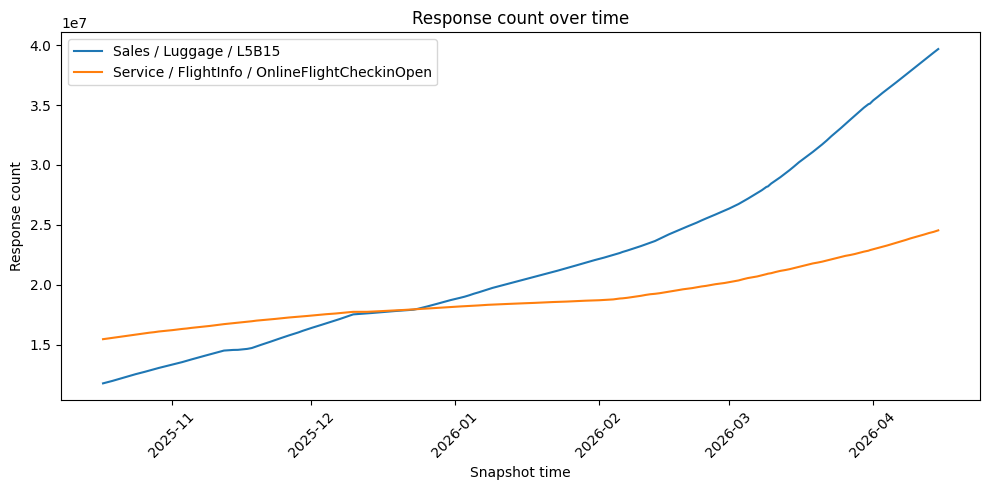

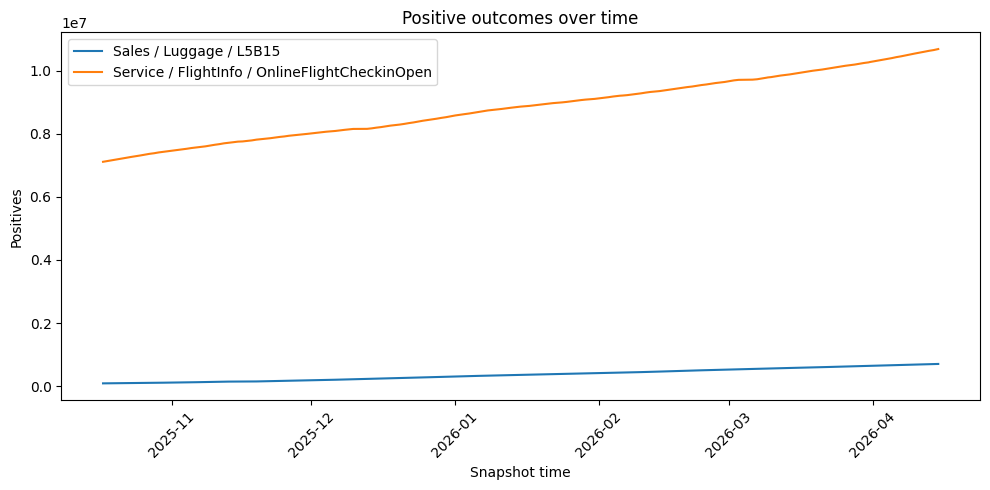

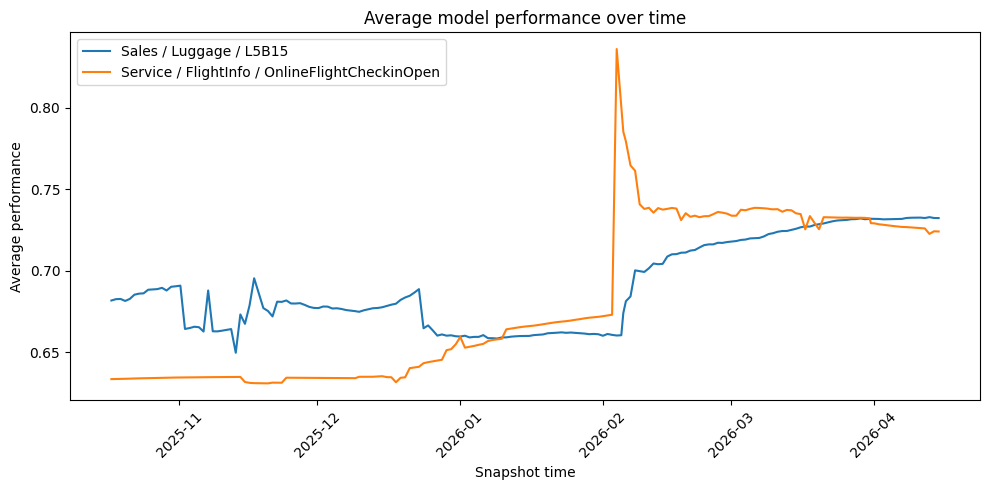

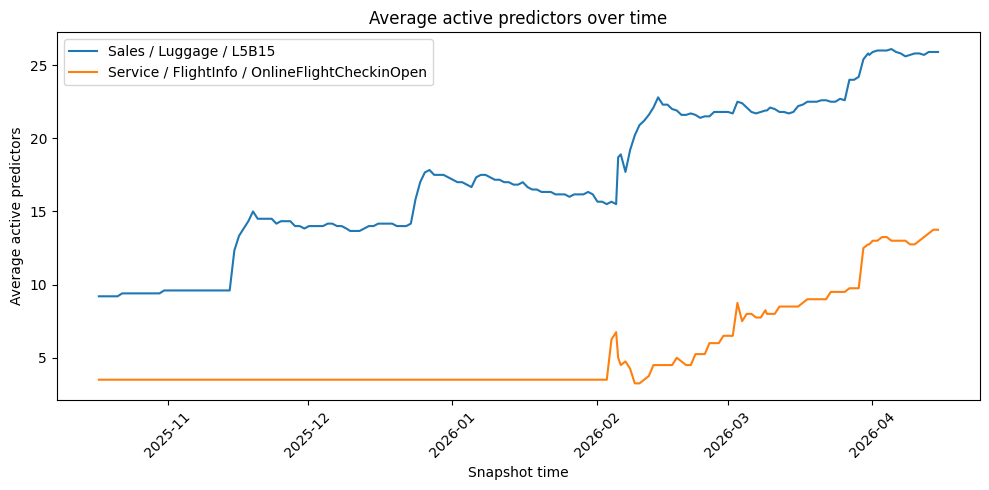

In [11]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# CONFIG: choose the two offers you want to compare
# --------------------------------------------------
OFFERS = [
    ("Service", "FlightInfo", "OnlineFlightCheckinOpen"),
    ("Sales", "Luggage", "L5B15"),
]

# --------------------------------------------------
# Helper: parse and prepare one offer
# --------------------------------------------------
def prepare_offer(df_model_snapshots, issue, group, name):
    df = df_model_snapshots.filter(
        (pl.col("pyIssue") == issue) &
        (pl.col("pyGroup") == group) &
        (pl.col("pyName") == name)
    )

    if df.height == 0:
        print(f"No rows found for {issue} / {group} / {name}")
        return None

    df = df.with_columns([
        pl.col("pyResponseCount").cast(pl.Float64, strict=False),
        pl.col("pyPositives").cast(pl.Float64, strict=False),
        pl.col("pyNegatives").cast(pl.Float64, strict=False),
        pl.col("pyActivePredictors").cast(pl.Float64, strict=False),
        pl.col("pyTotalPredictors").cast(pl.Float64, strict=False),
        pl.col("pyPerformance").cast(pl.Float64, strict=False),
        pl.col("pySuccessRate").cast(pl.Float64, strict=False),
        # Parse snapshot timestamp: keep first 15 chars like 20260415T015705
        pl.col("pySnapshotTime")
          .str.slice(0, 15)
          .str.strptime(pl.Datetime, format="%Y%m%dT%H%M%S", strict=False)
          .alias("snapshot_dt")
    ])

    # Aggregate per snapshot moment across model IDs
    out = (
        df.group_by("snapshot_dt")
        .agg([
            pl.col("pyResponseCount").sum().alias("response_count"),
            pl.col("pyPositives").sum().alias("positives"),
            pl.col("pyNegatives").sum().alias("negatives"),
            pl.col("pyActivePredictors").mean().alias("avg_active_predictors"),
            pl.col("pyTotalPredictors").mean().alias("avg_total_predictors"),
            pl.col("pyPerformance").mean().alias("avg_performance"),
            pl.col("pyModelID").n_unique().alias("n_models"),
        ])
        .sort("snapshot_dt")
        .with_columns([
            pl.lit(f"{issue} / {group} / {name}").alias("offer")
        ])
    )

    return out

# --------------------------------------------------
# Prepare both offers
# --------------------------------------------------
offer_frames = []
for issue, group, name in OFFERS:
    prepared = prepare_offer(df_model_snapshots, issue, group, name)
    if prepared is not None:
        offer_frames.append(prepared)

if not offer_frames:
    raise ValueError("No offer data found.")

plot_df = pl.concat(offer_frames).to_pandas()

# --------------------------------------------------
# Plot 1: Response count over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["response_count"], label=offer_name)
plt.title("Response count over time")
plt.xlabel("Snapshot time")
plt.ylabel("Response count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 2: Positives over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["positives"], label=offer_name)
plt.title("Positive outcomes over time")
plt.xlabel("Snapshot time")
plt.ylabel("Positives")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 3: Average model performance over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["avg_performance"], label=offer_name)
plt.title("Average model performance over time")
plt.xlabel("Snapshot time")
plt.ylabel("Average performance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 4: Average active predictors over time
# --------------------------------------------------
plt.figure(figsize=(10, 5))
for offer_name, group_df in plot_df.groupby("offer"):
    plt.plot(group_df["snapshot_dt"], group_df["avg_active_predictors"], label=offer_name)
plt.title("Average active predictors over time")
plt.xlabel("Snapshot time")
plt.ylabel("Average active predictors")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Model comparison over time

1. **Response volume**

    The L5B15 (luggage) model shows a strong increase in response volume over time, eventually surpassing the OnlineFlightCheckinOpen model. This indicates growing exposure and usage of the luggage offer. The check-in model shows steadier, more gradual growth.

2. **Positive outcomes**

    The OnlineFlightCheckinOpen model generates substantially more positive outcomes in absolute terms, reflecting its higher baseline engagement (consistent with a service interaction). In contrast, the luggage model has far fewer positives, which is expected for a purchase-driven offer.

3. **Model performance**

    Both models achieve comparable performance levels (~0.70–0.74) over time, indicating stable and effective learning. The check-in model shows a temporary spike followed by stabilization, while the luggage model improves more gradually, suggesting more incremental learning dynamics.

4. **Model complexity (active predictors)**

    The L5B15 (luggage) model consistently uses more active predictors and shows a clear increase over time (from ~9 to ~26), indicating growing model complexity and adaptation to richer patterns in the data. In contrast, the OnlineFlightCheckinOpen model starts with very few predictors (~3–4) and gradually increases to ~13–14, suggesting a simpler and more stable structure.